In [1]:
import pandas as pd
import numpy as np
import gseapy as gp
from gseapy.algorithm import enrichment_score
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from tqdm import tqdm

In [13]:
def get_safe_df(df, status_col='Status'):
    if status_col in df.columns:
        return df[df[status_col] == 'ok'].copy()
    return df.copy()

#Calculate Rank Score
# Compute Rank_Score robustly
def rank_score(df, p_col='P_value', lfc_col='Log2FC', seed=42):
    # 1. Chuyển đổi số và xử lý P-value bằng 0 (tránh log(0) = inf)
    np.random.seed(seed) 
    p_numeric = pd.to_numeric(df[p_col], errors='coerce').clip(lower=1e-300)
    lfc_numeric = pd.to_numeric(df[lfc_col], errors='coerce').fillna(0.0)
    
    # 2. Tính Rank Score cơ bản
    rank_score_values = np.sign(lfc_numeric) * (-np.log10(p_numeric))
    
    jitter = np.random.uniform(-1e-10, 1e-10, size=len(rank_score_values))
    rank_score_values += jitter

    ranked_df = df.assign(Rank_Score=rank_score_values)
    
    # 4. Loại bỏ các hàng NaN hoặc Inf (nếu có)
    # np.isinf kiểm tra cả dương và âm vô cùng
    ranked_results_df = ranked_df[
        ranked_df['Rank_Score'].notna() & (~np.isinf(ranked_df['Rank_Score']))
    ]
    
    if ranked_results_df.empty:
        print("Skipping: no valid Rank_Score values to run prerank.")
        return pd.DataFrame()
    
    # 5. Build rnk DataFrame chuẩn cho gseapy
    rnk = (ranked_results_df[['Gene', 'Rank_Score']]
           .groupby('Gene')
           .mean() # Đảm bảo mỗi Gene là duy nhất
           .sort_values('Rank_Score', ascending=False))
    return rnk


def cal_dwt(ori, syn):
    res_original = np.asarray(ori).reshape(-1,1)
    res_syn = np.asarray(syn).reshape(-1,1)

    dist, _ = fastdtw(res_original, res_syn, dist=euclidean)

    return dist



def get_wdt(ori_rank, syn_rank, gene_sets):
    # 1. Chạy GSEApy prerank cho cả 2 input một lần
    gp_orig = gp.prerank(rnk=ori_rank, gene_sets=gene_sets, verbose=False)
    gp_synth = gp.prerank(rnk=syn_rank, gene_sets=gene_sets, verbose=False)

    pathways = list(gene_sets.keys())
    
    all_results = {}
    for pathway in pathways:
        res_orig = gp_orig.results[pathway]['RES']
        res_synth = gp_synth.results[pathway]['RES']
        observed_dist = cal_dwt(res_orig,res_synth)
        all_results[pathway] = observed_dist

    return all_results, (gp_orig, gp_synth)




In [41]:
from gseapy.algorithm import enrichment_score
import numpy as np
from tqdm import tqdm

# Chuẩn bị dữ liệu một lần
pathway_name = list(gene_sets.keys())[0]
gene_set_dict = {pathway_name: gene_sets[pathway_name]}

# 1. Lấy gene list và correlation vector
gene_list = rnk_gene.index.values  # hoặc rnk_gene['Gene'].values
correl_vec = rnk_gene['Rank_Score'].values

# 2. Tính RES thực tế (observed)
es_orig, _, _, res_orig = enrichment_score(
    gene_list=gene_list,
    correl_vector=correl_vec,
    gene_set=gene_set_dict[pathway_name],
    weight=1.0,
    nperm=0,  # Không cần permutation ở đây
    single=False,
    scale=False
)

# Làm tương tự cho synthetic
gene_list_syn = syn_rnk_gene.index.values
correl_vec_syn = syn_rnk_gene['Rank_Score'].values

es_synth, _, _, res_synth = enrichment_score(
    gene_list=gene_list_syn,
    correl_vector=correl_vec_syn,
    gene_set=gene_set_dict[pathway_name],
    weight=1.0,
    nperm=0,
    single=False,
    scale=False
)

observed_dist = cal_dwt(res_orig, res_synth)

# 3. Permutation - TỐI ƯU HÓA
null_wdt_dist = []
n_permutations = 100

print("Đang chạy permutation...")
for i in tqdm(range(n_permutations)):
    # Tráo ngẫu nhiên correlation vector (NHANH HƠN)
    shuffled_correl = np.random.permutation(correl_vec_syn)
    
    # Tính RES trực tiếp
    _, _, _, res_perm = enrichment_score(
        gene_list=gene_list_syn,  # Giữ nguyên gene_list
        correl_vector=shuffled_correl,
        gene_set=gene_set_dict[pathway_name],
        weight=1.0,
        nperm=0,
        single=False,
        scale=False
    )
    
    d = cal_dwt(res_orig, res_perm)
    null_wdt_dist.append(d)

# 4. Normalization
null_mean = np.mean(null_wdt_dist)
null_std = np.std(null_wdt_dist)
n_wdt = (observed_dist - null_mean) / null_std

Đang chạy permutation...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [08:08<00:00,  4.88s/it]


In [18]:
#Original
seeds = [0,1,2,3,42]
original_dge = pd.read_csv(f'../DGE/DGE_Nivo/DGE_Origin.csv')
safe_dge = get_safe_df(original_dge)
rnk_gene = rank_score(safe_dge)



for seed in seeds:
    print(f"*******{seed}*******")
    synthetic_dict = {
        'Avatars K5': f'../DGE/DGE_Nivo/Seed_{seed}/DGE_avatarsk5_{seed}.csv',
        'Avatars K10': f'../DGE/DGE_Nivo/Seed_{seed}/DGE_avatarsk10_{seed}.csv',
        'CTGAN': f'../DGE/DGE_Nivo/Seed_{seed}/DGE_ctgan_{seed}.csv',
        'Gaussian Copula': f'../DGE/DGE_Nivo/Seed_{seed}/DGE_gaussiancopula_{seed}.csv',
        'Synthpop': f'../DGE/DGE_Nivo/Seed_{seed}/DGE_synthpop_{seed}.csv',
        'TVAE': f'../DGE/DGE_Nivo/Seed_{seed}/DGE_tvae_{seed}.csv',
    }
    
    
    
    
    hallmarks_gmt  = "h.all.v2025.1.Hs.symbols.gmt"
    gene_sets = gp.read_gmt(hallmarks_gmt)
    
    DWT_Results = {}
    for tool, path in synthetic_dict.items():
        try:
            print(f'----{tool}----')
            synthetic_dge = pd.read_csv(path)
            safe_syn = get_safe_df(synthetic_dge)
            syn_rnk_gene = rank_score(safe_syn)
            dwt_results, _ = get_wdt(ori_rank = rnk_gene, syn_rank = syn_rnk_gene, gene_sets = gene_sets)
            DWT_Results[tool] = dwt_results
        except Exception as err:
            print(f"Skipping {tool}: could not read {path}: {err}")

    df_wdt = pd.DataFrame(DWT_Results)
    df_wdt.to_csv(f'WDT/WDT_{seed}.csv', index = True)

*******0*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----


2026-01-26 13:21:55,228 [WARNING] Duplicated values found in preranked stats: 0.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


----TVAE----
Skipping TVAE: could not read ../DGE/DGE_Nivo/Seed_0/DGE_tvae_0.csv: [Errno 2] No such file or directory: '../DGE/DGE_Nivo/Seed_0/DGE_tvae_0.csv'
*******1*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----


2026-01-26 13:43:23,017 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


----TVAE----
Skipping TVAE: could not read ../DGE/DGE_Nivo/Seed_1/DGE_tvae_1.csv: [Errno 2] No such file or directory: '../DGE/DGE_Nivo/Seed_1/DGE_tvae_1.csv'
*******2*******
----Avatars K5----


2026-01-26 13:47:47,020 [WARNING] Duplicated values found in preranked stats: 0.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----
Skipping TVAE: could not read ../DGE/DGE_Nivo/Seed_2/DGE_tvae_2.csv: [Errno 2] No such file or directory: '../DGE/DGE_Nivo/Seed_2/DGE_tvae_2.csv'
*******3*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----
Skipping TVAE: could not read ../DGE/DGE_Nivo/Seed_3/DGE_tvae_3.csv: [Errno 2] No such file or directory: '../DGE/DGE_Nivo/Seed_3/DGE_tvae_3.csv'
*******42*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----
Skipping TVAE: could not read ../DGE/DGE_Nivo/Seed_42/DGE_tvae_42.csv: [Errno 2] No such file or directory: '../DGE/DGE_Nivo/Seed_42/DGE_tvae_42.csv'


In [62]:
WDT_seed = {}
for seed in seeds:
    df_res = pd.read_csv(f'WDT/WDT_{seed}.csv', index_col = 0)
    score = df_res.mean()
    WDT_seed[seed] = score

In [67]:
from collections import defaultdict

scores_by_tool = defaultdict(list)

for seed_dict in WDT_seed.values():
    for key, score in seed_dict.items():
        tool = key.rsplit("_", 1)[0]   # bỏ seed
        scores_by_tool[tool].append(score)

# Tính average
avg_scores = {tool: np.mean(scores) for tool, scores in scores_by_tool.items()}

avg_scores

{'Avatars K5': 3187.582251031381,
 'Avatars K10': 2549.407147508956,
 'CTGAN': 2172.6660961766866,
 'Gaussian Copula': 3152.5165055763014,
 'Synthpop': 3813.689178115996}

In [66]:
scores_by_tool

defaultdict(list,
            {'Avatars K5': [3434.778506172044,
              3334.59691639881,
              3327.9372338980847,
              3385.4775479860273,
              2455.1210507019387],
             'Avatars K10': [2132.1319531371414,
              1775.022830381996,
              1909.1595913529568,
              3684.8242152849825,
              3245.8971473877027],
             'CTGAN': [2089.0393116341224,
              2331.137390572336,
              1999.5313142995415,
              2418.3537485776164,
              2025.268715799817],
             'Gaussian Copula': [2532.4322574062157,
              4522.3755750835035,
              3841.5742693795137,
              3667.5972759376705,
              1198.6031500746026],
             'Synthpop': [4840.536538129759,
              3957.1633741303704,
              5367.448862704769,
              3083.1095417252345,
              1820.1875738898502]})

/tmp/ipykernel_39874/2393682141.py:49: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_39874/2393682141.py:64: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


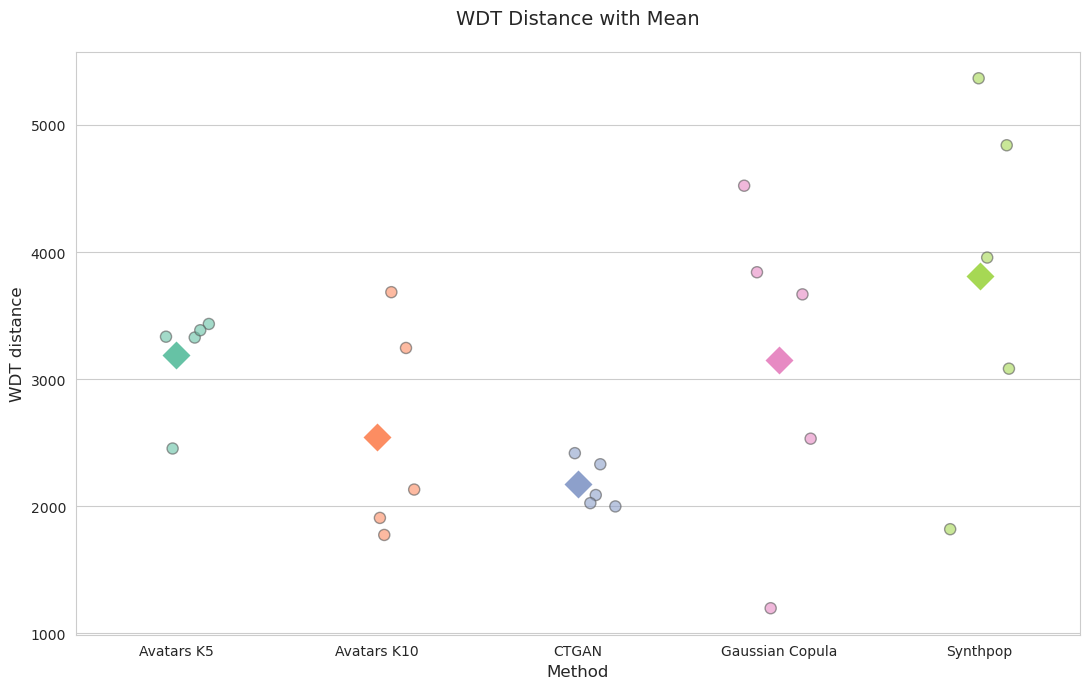

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dữ liệu đầu vào
data =             {'Avatars K5': [3434.778506172044,
              3334.59691639881,
              3327.9372338980847,
              3385.4775479860273,
              2455.1210507019387],
             'Avatars K10': [2132.1319531371414,
              1775.022830381996,
              1909.1595913529568,
              3684.8242152849825,
              3245.8971473877027],
             'CTGAN': [2089.0393116341224,
              2331.137390572336,
              1999.5313142995415,
              2418.3537485776164,
              2025.268715799817],
             'Gaussian Copula': [2532.4322574062157,
              4522.3755750835035,
              3841.5742693795137,
              3667.5972759376705,
              1198.6031500746026],
             'Synthpop': [4840.536538129759,
              3957.1633741303704,
              5367.448862704769,
              3083.1095417252345,
              1820.1875738898502]}

DATASET_COLORS = {
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
}

# 2. Chuyển đổi dữ liệu
df = pd.DataFrame([(k, v) for k, values in data.items() for v in values], 
                  columns=['Dataset', 'Direction Agreement'])

# 3. Vẽ biểu đồ
plt.figure(figsize=(11, 7))
sns.set_style("whitegrid")

# Vẽ Stripplot (các điểm dữ liệu gốc)
sns.stripplot(
    data=df, 
    x='Dataset', 
    y='Direction Agreement', 
    palette=DATASET_COLORS, 
    hue='Dataset',
    jitter=0.2, 
    size=8, 
    alpha=0.6,      # Làm mờ các điểm gốc một chút để nổi bật điểm Mean
    linewidth=1,
    edgecolor='gray',
    legend=False
)

# Vẽ Pointplot để hiển thị giá trị Mean dưới dạng Diamond
sns.pointplot(
    data=df, 
    x='Dataset', 
    y='Direction Agreement', 
    estimator='mean',     # Tính giá trị trung bình
    errorbar=None,        # Không vẽ thanh sai số (error bars)
    markers='D',          # 'D' là ký hiệu cho hình Kim cương (Diamond)
    markersize=12,        # Kích thước kim cương lớn hơn để dễ nhìn
    palette=DATASET_COLORS, 
    hue='Dataset',
    join=False            # Không nối các điểm trung bình lại với nhau
)

# 4. Tinh chỉnh tiêu đề và trục
plt.title('WDT Distance with Mean', fontsize=14, pad=20)
plt.ylabel('WDT distance', fontsize=12)
plt.xlabel('Method', fontsize=12)
plt.tight_layout()
plt.show()

## Agreement Direction

In [51]:
gsea_ori = pd.read_csv('NivoBenefit/Seed_42/GSEA_Origin.csv')
gsea_syn = pd.read_csv('NivoBenefit/Seed_42/GSEA_gaussiancopula_42.csv')

In [52]:

def calculate_direction_agreement(df_orig, df_synth):
    """
    Calculates the percentage of gene sets that share the same 
    enrichment direction (positive or negative NES).
    """
    # 1. Keep only necessary columns and rename for clarity
    orig = df_orig[['Term', 'NES']].rename(columns={'NES': 'NES_orig'})
    synth = df_synth[['Term', 'NES']].rename(columns={'NES': 'NES_synth'})
    
    # 2. Merge tables on the gene set Term
    # Inner join ensures we only compare terms present in both datasets
    merged = pd.merge(orig, synth, on='Term', how='inner')
    
    if merged.empty:
        return "No common gene sets found between datasets."

    # 3. Calculate agreement: Sign(NES_orig) == Sign(NES_synth)
    # np.sign returns -1 for negative, 1 for positive, and 0 for zero
    merged['agreement'] = np.sign(merged['NES_orig']) == np.sign(merged['NES_synth'])
    
    agreement_count = merged['agreement'].sum()
    total_common = len(merged)
    percentage = (agreement_count / total_common) * 100
    
    return {
        'total_common_terms': total_common,
        'agreement_count': agreement_count,
        'agreement_percentage': percentage,
        'merged_df': merged
    }

# Usage:
results = calculate_direction_agreement(gsea_ori, gsea_syn)
# print(f"Direction Agreement: {results['agreement_percentage']:.2f}%")

In [54]:
#Original
seeds = [0,1,2,3,42]
gsea_ori = pd.read_csv('NivoBenefit/Seed_42/GSEA_Origin.csv')
AD_seed = {}
for seed in seeds:
    print(f"*******{seed}*******")
    synthetic_dict = {
        'Avatars K5': f'NivoBenefit/Seed_{seed}/GSEA_avatarsk5_{seed}.csv',
        'Avatars K10': f'NivoBenefit/Seed_{seed}/GSEA_avatarsk10_{seed}.csv',
        'CTGAN': f'NivoBenefit/Seed_{seed}/GSEA_ctgan_{seed}.csv',
        'Gaussian Copula': f'NivoBenefit/Seed_{seed}/GSEA_gaussiancopula_{seed}.csv',
        'Synthpop': f'NivoBenefit/Seed_{seed}/GSEA_synthpop_{seed}.csv',
        'TVAE': f'NivoBenefit/Seed_{seed}/GSEA_tvae_{seed}.csv',
    }
    
    
    
    
    hallmarks_gmt  = "h.all.v2025.1.Hs.symbols.gmt"
    gene_sets = gp.read_gmt(hallmarks_gmt)
    
    ArgreementDirection_Results = {}
    for tool, path in synthetic_dict.items():
        try:
            print(f'----{tool}----')
            gsea_syn = pd.read_csv(path)
            results =  calculate_direction_agreement(gsea_ori, gsea_syn)
            ArgreementDirection_Results[tool] = results['agreement_percentage']
        except Exception as err:
            print(f"Skipping {tool}: could not read {path}: {err}")

    AD_seed[seed] = ArgreementDirection_Results

*******0*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----
Skipping TVAE: could not read NivoBenefit/Seed_0/GSEA_tvae_0.csv: [Errno 2] No such file or directory: 'NivoBenefit/Seed_0/GSEA_tvae_0.csv'
*******1*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----
Skipping TVAE: could not read NivoBenefit/Seed_1/GSEA_tvae_1.csv: [Errno 2] No such file or directory: 'NivoBenefit/Seed_1/GSEA_tvae_1.csv'
*******2*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----
Skipping TVAE: could not read NivoBenefit/Seed_2/GSEA_tvae_2.csv: [Errno 2] No such file or directory: 'NivoBenefit/Seed_2/GSEA_tvae_2.csv'
*******3*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----
Skipping TVAE: could not read NivoBenefit/Seed_3/GSEA_tvae_3.csv: [Errno 2] No such file

In [56]:
from collections import defaultdict

scores_by_tool = defaultdict(list)

for seed_dict in AD_seed.values():
    for key, score in seed_dict.items():
        tool = key.rsplit("_", 1)[0]   # bỏ seed
        scores_by_tool[tool].append(score)

# Tính average
avg_scores = {tool: np.mean(scores) for tool, scores in scores_by_tool.items()}

avg_scores

{'Avatars K5': 63.6,
 'Avatars K10': 65.2,
 'CTGAN': 48.4,
 'Gaussian Copula': 57.2,
 'Synthpop': 46.4}

/tmp/ipykernel_39874/3071576598.py:31: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_39874/3071576598.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


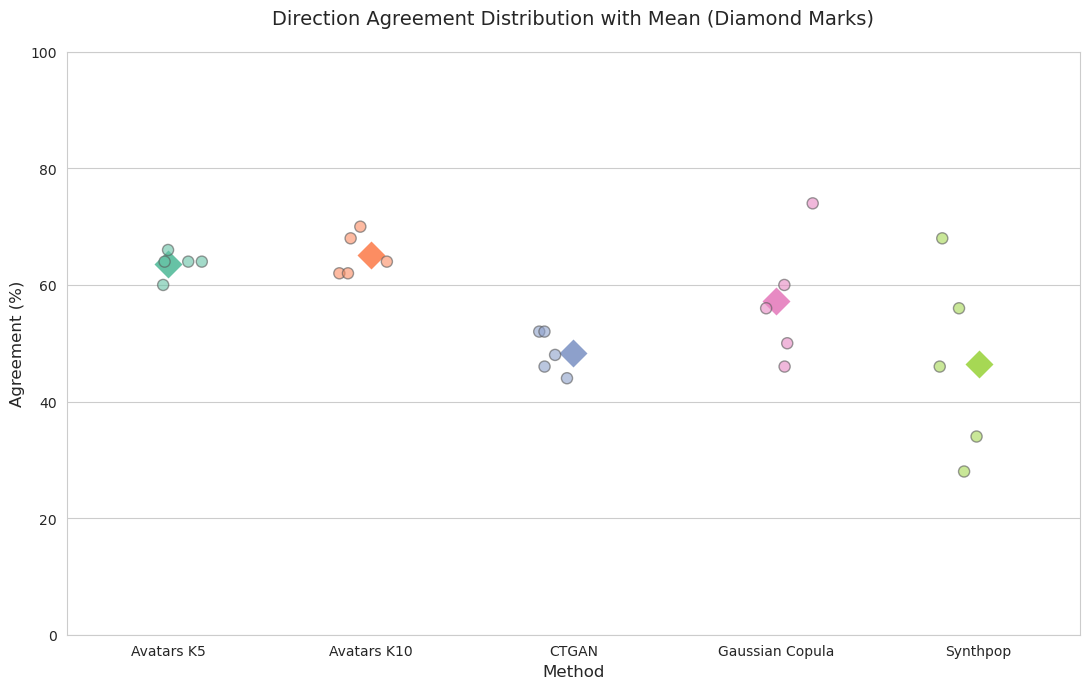

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dữ liệu đầu vào
data = {
    'Avatars K5': [64.0, 64.0, 60.0, 64.0, 66.0],
    'Avatars K10': [62.0, 68.0, 70.0, 62.0, 64.0],
    'CTGAN': [48.0, 44.0, 52.0, 46.0, 52.0],
    'Gaussian Copula': [56.0, 46.0, 60.0, 50.0, 74.0],
    'Synthpop': [28.0, 34.0, 46.0, 56.0, 68.0]
}

DATASET_COLORS = {
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
}

# 2. Chuyển đổi dữ liệu
df = pd.DataFrame([(k, v) for k, values in data.items() for v in values], 
                  columns=['Dataset', 'Direction Agreement'])

# 3. Vẽ biểu đồ
plt.figure(figsize=(11, 7))
sns.set_style("whitegrid")

# Vẽ Stripplot (các điểm dữ liệu gốc)
sns.stripplot(
    data=df, 
    x='Dataset', 
    y='Direction Agreement', 
    palette=DATASET_COLORS, 
    hue='Dataset',
    jitter=0.2, 
    size=8, 
    alpha=0.6,      # Làm mờ các điểm gốc một chút để nổi bật điểm Mean
    linewidth=1,
    edgecolor='gray',
    legend=False
)

# Vẽ Pointplot để hiển thị giá trị Mean dưới dạng Diamond
sns.pointplot(
    data=df, 
    x='Dataset', 
    y='Direction Agreement', 
    estimator='mean',     # Tính giá trị trung bình
    errorbar=None,        # Không vẽ thanh sai số (error bars)
    markers='D',          # 'D' là ký hiệu cho hình Kim cương (Diamond)
    markersize=12,        # Kích thước kim cương lớn hơn để dễ nhìn
    palette=DATASET_COLORS, 
    hue='Dataset',
    join=False            # Không nối các điểm trung bình lại với nhau
)

# 4. Tinh chỉnh tiêu đề và trục
plt.title('Direction Agreement Distribution with Mean (Diamond Marks)', fontsize=14, pad=20)
plt.ylabel('Agreement (%)', fontsize=12)
plt.xlabel('Method', fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()